In [43]:
import pandas as pd

In [44]:
df = pd.read_csv('bestsellers with categories.csv')
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [45]:
df = df.drop(columns=['Price', 'Genre'])
df

,Name,Author,User Rating,Reviews,Year
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,2016
1,11/22/63: A Novel,Stephen King,4.6,2052,2011
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,2018
3,1984 (Signet Classics),George Orwell,4.7,21424,2017
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,2019
...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,2019
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,2016
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,2017
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,2018


In [46]:
df.describe()

,User Rating,Reviews,Year
count,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,2014.000000
std,0.226980,11731.132017,3.165156
min,3.300000,37.000000,2009.000000
25%,4.500000,4058.000000,2011.000000
50%,4.700000,8580.000000,2014.000000
75%,4.800000,17253.250000,2017.000000
max,4.900000,87841.000000,2019.000000


In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    str    
 1   Author       550 non-null    str    
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Year         550 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 55.1 KB


In [48]:
df.memory_usage(deep=True)

Index            132
Name           31203
Author         11906
User Rating     4400
Reviews         4400
Year            4400
dtype: int64

In [49]:
df.to_parquet('bestsellers with categories.parquet', index = False)

In [50]:
df.to_excel('bestsellers with categories.xlsx', index = False)

In [51]:
numeric_cols = df.select_dtypes(include='number')
X = numeric_cols.drop(columns=['User Rating'], errors='ignore')
y = df['User Rating']

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)
dados = pd.DataFrame(
    pca.transform(X),
    columns=['PC1', 'PC2']
)
dados['User Rating'] = y.values
print(pca.explained_variance_ratio_)


[9.99999932e-01 6.77397833e-08]


In [53]:
dados.corr().style.background_gradient(cmap='coolwarm')

,PC1,PC2,User Rating
PC1,1.000000,-0.000000,-0.001729
PC2,-0.000000,1.000000,0.251739
User Rating,-0.001729,0.251739,1.000000


In [54]:
print(dados.head())
print(dados.describe())
print(dados.info())

           PC1       PC2  User Rating
0  5396.718310  1.616236          4.7
1 -9901.282006 -2.295914          4.6
2  7025.718448  3.500397          4.7
3  9470.718371  2.326532          4.7
4 -4288.281452  5.304942          4.8
                PC1           PC2  User Rating
count  5.500000e+02  5.500000e+02   550.000000
mean   4.233284e-13  1.107930e-13     4.618364
std    1.173113e+04  3.053246e+00     0.226980
min   -1.191628e+04 -5.552296e+00     3.300000
25%   -7.895282e+03 -2.599059e+00     4.500000
50%   -3.373282e+03 -3.254607e-01     4.700000
75%    5.299968e+03  2.535429e+00     4.800000
max    7.588772e+04  5.654877e+00     4.900000
<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PC1          550 non-null    float64
 1   PC2          550 non-null    float64
 2   User Rating  550 non-null    float64
dtypes: float64(3)
memory usage: 13.0 KB
None


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_cols = df.select_dtypes(include='number').drop(columns=['User Rating'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_cols)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

dados = pd.DataFrame(X_pca, columns=['PC1','PC2'])
dados['User Rating'] = df['User Rating'].values

print(pca.explained_variance_ratio_)

[0.6317798 0.3682202]


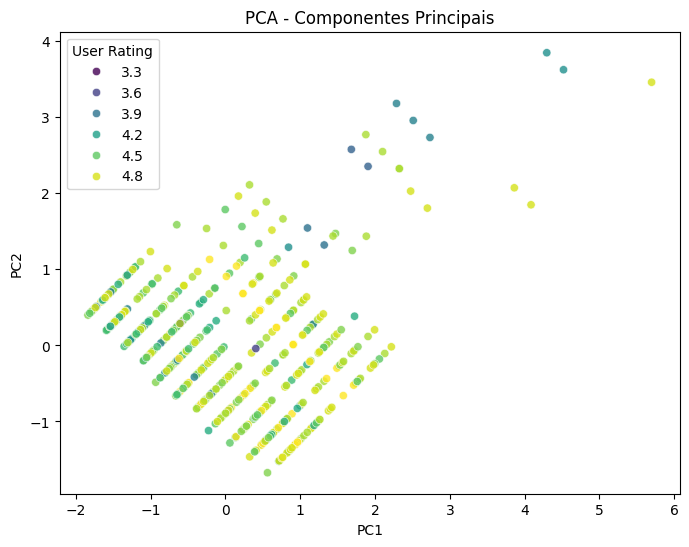

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=dados, x='PC1', y='PC2', hue='User Rating', palette='viridis', alpha=0.8)
plt.title('PCA - Componentes Principais')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()